<a href="https://colab.research.google.com/github/RashmiBansode2002/Conversion-of-Text-to-Gloss-for-Sign-Language/blob/main/ISL_corpus_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <center>Calculate \& Display ISL corpus statistics</center>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Imports

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import statistics

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

### Corpus data

In [ ]:
"""
These are the paths to the two phoenix corpus text files stored locally
english: the english sentences
glosses: the gloss sentences

"""
data_dir = Path('path')

english_stripped = data_dir / 'english_stripped_train.txt'
glosses = data_dir / 'glosses_train.txt'

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

### Define functions

In [ ]:
"""
This is a function that measures the length of each sentence from the corpus.
It counts each word (could also be a number).
Empty spaces and new lines are not counted as characters.

The function takes as an input a text file OR csv file
where each line is a separate sentence stripped from punctuation.

The function starts with an empty array to which each tumple will be added.
It goes through each line of the text/ csv file, splits the line where there are
empty spaces into single strings and counts their number.

Then it creates a tuple in the form of (sentence, length),
where sentence is the initial line of the text file (str)
and length is the number of single words in the sentence (int).

The function returns a list of tuples with two elements each.

Parameters
----------
in_txt : text/csv file

"""

def measure_sentence_length(in_txt) -> list:

    sentence_and_length = []

    with open(in_txt, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip('\n')
            # split the sentence into its compound parts (words)
            words = line.split(' ')
            # initialize a counter for the length
            sentence_length = 0
            # count each word and increase the counter
            for i in range(0, len(words)):
                sentence_length = sentence_length + 1
            sentence_and_length.append((line, sentence_length))
    f.close()
    return sentence_and_length

In [ ]:
"""
This is a function that takes a list of tuples with two elements
in the form (sentence, length) and sorts the list first according
to the second element in the tuple, which is the length (int).

The function returns a sorted list of tuples with two elements each.

Parameters
----------
in_lst : list

"""

def sort_sentences(in_list) -> list:
    return sorted(in_list, key=lambda x:(x[1], x[0]))

In [ ]:
"""
This is a function that takes a list of tuples with two elements each
in the form (sentence, length) and calculates the mean of the lengths.

The function returns float.

Parameters
----------
in_lst : list

"""

def calculate_mean(in_list) -> float:
    lengths = []
    for element in in_list:
        lengths.append(element[1])
    return statistics.mean(lengths)

In [ ]:
"""
This is a function that takes a list of tuples with two elements each
in the form (sentence, length) and calculates the standard deviation
of the lengths.

The function returns float.

Parameters
----------
in_lst : list

"""

def calculate_std(in_list) -> float:
    lengths = []
    for element in in_list:
        lengths.append(element[1])
    return statistics.pstdev(lengths)

In [ ]:
"""
This is a function that creates a bar graph.
It takes a single list of tuples as an
argument.

Parameters
----------
in_lst : list

"""

def sentences_plot(in_list):

    fig = plt.figure()
    ax = fig.add_axes([0, 0, 3, 1])

    # plot the lengths of the english/ gloss sentences
    x1 = [x for x in range(0, len(in_list))]
    y1 = [y[1] for y in in_list]
    plt.plot(x1, y1)

    plt.xlabel('Sentence from the trainig set')
    plt.ylabel('Length of the sentence in words')

    plt.show()

In [ ]:
"""
This is a function that creates a line graph.
It takes two lists as arguments.

Parameters
----------
in_english : list of tuples with english sentences
in_glosses: list of tuples with gloss sentences

"""

def shared_plot(in_english, in_glosses):

    fig = plt.figure()
    ax = fig.add_axes([0, 0, 2, 1])

    # plot the lengths of the english sentences
    x1 = [x for x in range(0, len(in_english))]
    y1 = [y[1] for y in in_english]
    plt.plot(x1, y1, label = "english sentences")

    # plot the lengths of the gloss sentences
    x2 = [x for x in range(0, len(in_glosses))]
    y2 = [y[1] for y in in_glosses]
    plt.plot(x2, y2, label = "Gloss sentences")

    # axes labels
    plt.xlabel('Sentence from the trainig set')
    plt.ylabel('Length of the sentence in words')

    plt.title('Compare english and gloss sentences lengths')
    plt.legend()
    plt.show()

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

---

### 1. Statistics for the english sentences of the corpus

#### Measure the length of each sentence

In [ ]:
import pandas as pd

def measure_sentence_length_excel(file_path, sheet_name):
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        sentences = df['text'].tolist()
        sentence_lengths = [len(str(sentence).split()) for sentence in sentences]
        return sentence_lengths
    except Exception as e:
        print("Error:", e)
        return []

# Example usage:
file_path = "/content/drive/MyDrive/Copy of Sentences to Glosses.xlsx"
sheet_name = 'Sheet1'
lengths = measure_sentence_length_excel(file_path, sheet_name)
print("Sentence lengths:", lengths)


Sentence lengths: [3, 3, 5, 4, 5, 4, 5, 6, 3, 3, 5, 6, 5, 5, 3, 5, 5, 4, 3, 3, 3, 5, 5, 3, 3, 5, 5, 6, 5, 5, 5, 5, 5, 5, 5, 6, 5, 5, 3, 3, 5, 6, 4, 4, 5, 5, 5, 4, 6, 5, 4, 5, 11, 6, 4, 4, 4, 4, 4, 3, 4, 2, 3, 4, 4, 3, 5, 5, 5, 4, 5, 4, 4, 3, 3, 5, 4, 3, 3, 3, 4, 2, 2]


#### Display the first 10

In [ ]:
import pandas as pd

def measure_sentence_length(sentences):
    sentence_lengths = [len(sentence.split()) for sentence in sentences]
    return sentence_lengths

def display_first_10_sentences_with_lengths(file_path):
    try:
        df = pd.read_excel(file_path)
        sentences = df.iloc[:10, 0].tolist()  # Assuming sentences are in the first column
        lengths = measure_sentence_length(sentences)
        for i, sentence in enumerate(sentences):
            print(f"{sentence.strip()} ({lengths[i]} words)")
            if i+1 < len(sentences):
                print()
    except Exception as e:
        print("Error:", e)

# Example usage:
file_path = "/content/drive/MyDrive/Copy of Sentences to Glosses.xlsx"
sheet_name = 'Sheet1'
display_first_10_sentences_with_lengths(file_path)


i am angry (3 words)

you are angry (3 words)

you are angry with me (5 words)

you are not angry (4 words)

i am so much angry (5 words)

i am very angry (4 words)

you are so much angry (5 words)

i promise not to be angry (6 words)

you are bad (3 words)

i am bad (3 words)


#### There are a lot of sentences that consist of only one word.

In [ ]:
sorted_english_sentences = sorted(lengths)

#### Display the longest english sentence

In [ ]:
longest_sentence_length = sorted_english_sentences[-1]
formatted_output = f"Longest sentence length is: {longest_sentence_length}."
print(formatted_output)

Longest sentence length is: 11.


#### Calculate the mean of the lengths

In [ ]:
def calculate_mean(sentence_lengths):
    total_length = sum(sentence_lengths)
    mean_length = total_length / len(sentence_lengths)
    return mean_length

mean_length_english = calculate_mean(lengths)
print(f"The mean sentence length in english is: {mean_length_english}")

The mean sentence length in english is: 4.325301204819277


#### Calculate the std of the lengths

In [ ]:
def calculate_std(sentence_lengths):
    std_dev = statistics.stdev(sentence_lengths)
    return std_dev

std_dev_english = calculate_std(lengths)
print(f"The standard deviation of sentence lengths in english is: {std_dev_english}")

The standard deviation of sentence lengths in english is: 1.269803458336529


---

### 2. Visualize the lengths of the english sentences

#### Plot the english sentences without sorting them

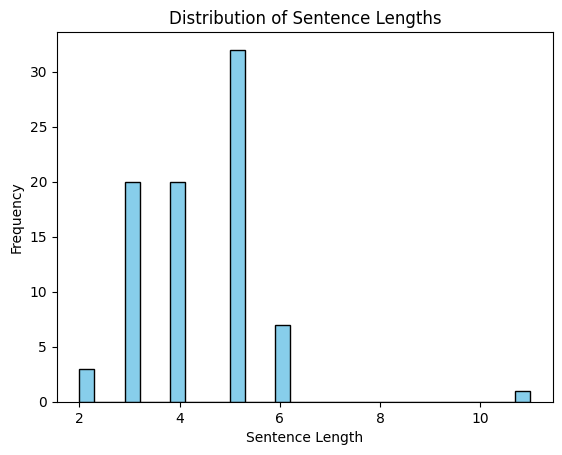

In [ ]:
import matplotlib.pyplot as plt

def sentences_plot(lengths):
    plt.hist(lengths, bins=30, color='skyblue', edgecolor='black')
    plt.xlabel('Sentence Length')
    plt.ylabel('Frequency')
    plt.title('Distribution of Sentence Lengths')
    plt.show()

sentences_plot(lengths)


#### Plot the sorted english sentences

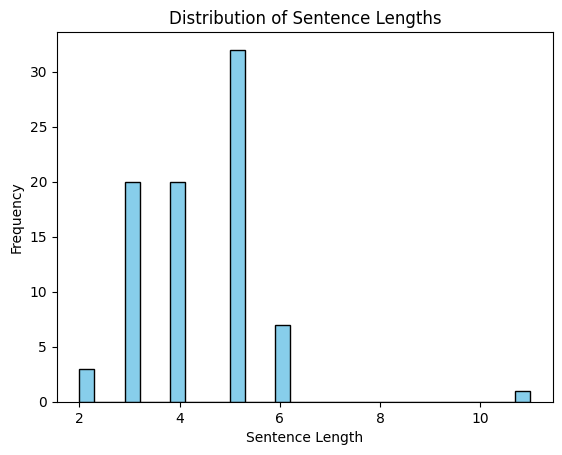

In [ ]:
# import matplotlib.pyplot as plt

# def sentences_plot(sorted_sentence_lengths):
#     plt.plot(sorted_sentence_lengths, color='skyblue')
#     plt.xlabel('Sentence Index')
#     plt.ylabel('Sentence Length')
#     plt.title('Sorted Sentence Lengths in english')
#     plt.grid(True)
#     plt.show()

sentences_plot(sorted_english_sentences)


### 3. Statistics for the gloss side of the corpus

#### Measure the length of each gloss sentence

In [ ]:
def measure_sentence_length(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        sentences = file.readlines()
        sentence_lengths = [len(sentence.split()) for sentence in sentences]
    return sentence_lengths

file_path = "/content/drive/MyDrive/text-to-gloss-sign-language-translation-main/Data/gloss 1 train.csv"
measured_gloss_sentences = measure_sentence_length(file_path)


#### Display the first 10

In [ ]:
def measure_sentence_length(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        sentences = file.readlines()
        sentence_lengths = [len(sentence.split()) for sentence in sentences]
    return sentence_lengths

def display_first_10_glosses_with_next_length(file_path):
    glosses = []
    with open(file_path, 'r', encoding='utf-8') as file:
        glosses = file.readlines()[:10]

    lengths = measure_sentence_length(file_path)
    for i, gloss in enumerate(glosses):
        print(f"{gloss.strip()} ({lengths[i]} words)")
        print()

# Replace 'glosses_stem_train.txt' with the correct file path to your glosses file
file_path = "/content/drive/MyDrive/text-to-gloss-sign-language-translation-main/Data/gloss 1 train.csv"
display_first_10_glosses_with_next_length(file_path)


gloss (1 words)

I angry (2 words)

you angry (2 words)

angry you me (3 words)

you angry not (3 words)

I angry very (3 words)

I angry very (3 words)

you angry very (3 words)

promise I angry not (4 words)

you bad (2 words)



#### Sort the list of tuples according to the gloss sentence length

In [ ]:
sorted_gloss_sentences = sorted(measured_gloss_sentences)

#### Display the longest gloss sentence

In [ ]:
# Assuming sorted_gloss_sentences contains tuples of (gloss, length)
longest_gloss_tuple = sorted_gloss_sentences[-1]
formatted_output = f"Longest sentence length is: {longest_gloss_tuple}."
print(formatted_output)

Longest sentence length is: 7.


#### Calculate the mean of the lengths

In [ ]:
calculate_mean(measured_gloss_sentences)

0.2783400809716599

#### Caluclate the std of the lengths

In [ ]:
calculate_std(measured_gloss_sentences)

0.9604417242638849

### 4. Visualize the lengths of the gloss sentences

#### Plot the gloss sentences without sorting them

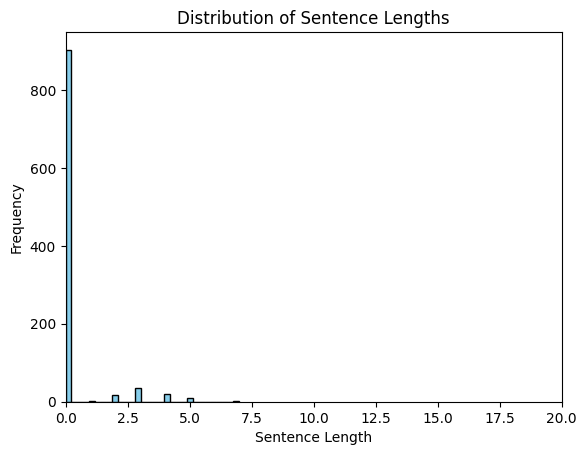

In [ ]:
plt.xlim(0, 20)
sentences_plot(measured_gloss_sentences)

#### Plot the sorted gloss sentences

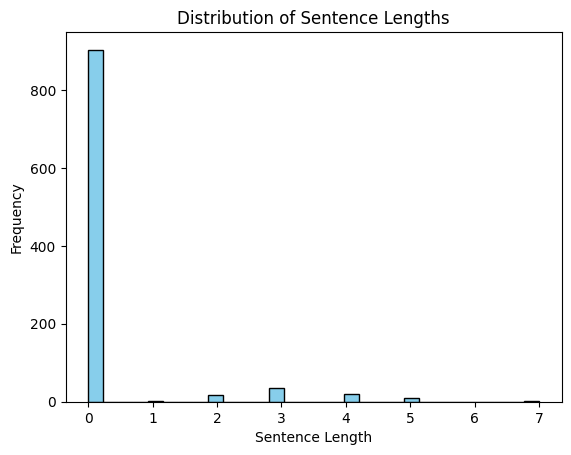

In [ ]:
sentences_plot(sorted_gloss_sentences)

---

### 5. Compare the lengths of the english and gloss sentences

#### Without sorting

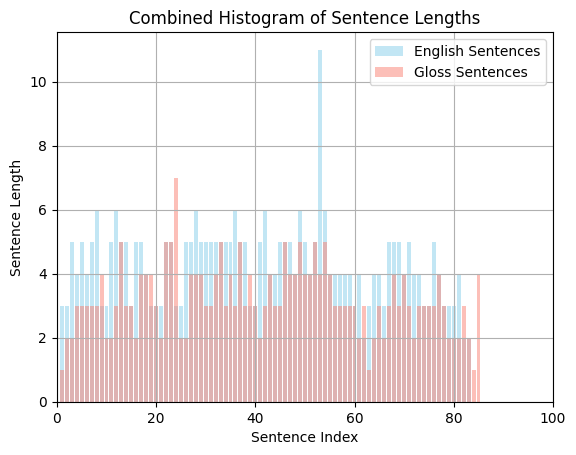

In [ ]:
import matplotlib.pyplot as plt

def combined_histogram(english_lengths, gloss_lengths):
    # Create lists for x-values (sentence index) and y-values (sentence length)
    english_indices = list(range(1, len(english_lengths) + 1))
    gloss_indices = list(range(1, len(gloss_lengths) + 1))

    # Plot the histogram for english sentences
    plt.bar(english_indices, english_lengths, color='skyblue', alpha=0.5, label='English Sentences')

    # Plot the histogram for gloss sentences on top of the english sentences
    plt.bar(gloss_indices, gloss_lengths, color='salmon', alpha=0.5, label='Gloss Sentences')

    plt.xlabel('Sentence Index')
    plt.ylabel('Sentence Length')
    plt.title('Combined Histogram of Sentence Lengths')
    plt.legend()
    plt.grid(True)

    # Set x-axis limits from 0 to 200
    plt.xlim(0, 100)

    plt.show()

# Call the combined histogram function with the measured lengths for both english and gloss sentences
combined_histogram(lengths, measured_gloss_sentences)